Figure 1

[rcp26_ssp1] 17% PA (2080 - 2015) -> Min: -85.71%, Max: 100.00%
[rcp26_ssp1] 30% PA ("biodiversity-only" - 17% PA 2080) -> Min: -100.00%, Max: 100.00%
[rcp26_ssp2] 17% PA (2080 - 2015) -> Min: -100.00%, Max: 100.00%
[rcp26_ssp2] 30% PA ("biodiversity-only" - 17% PA 2080) -> Min: -73.07%, Max: 100.00%
[rcp60_ssp4] 17% PA (2080 - 2015) -> Min: -99.90%, Max: 100.00%
[rcp60_ssp4] 30% PA ("biodiversity-only" - 17% PA 2080) -> Min: -100.00%, Max: 100.00%

✅ Figure saved at: /capacity/occr_davin/mguzman/chari_P2_review/Endemics/Previous_results/Figures/F1_SR_2x3.png


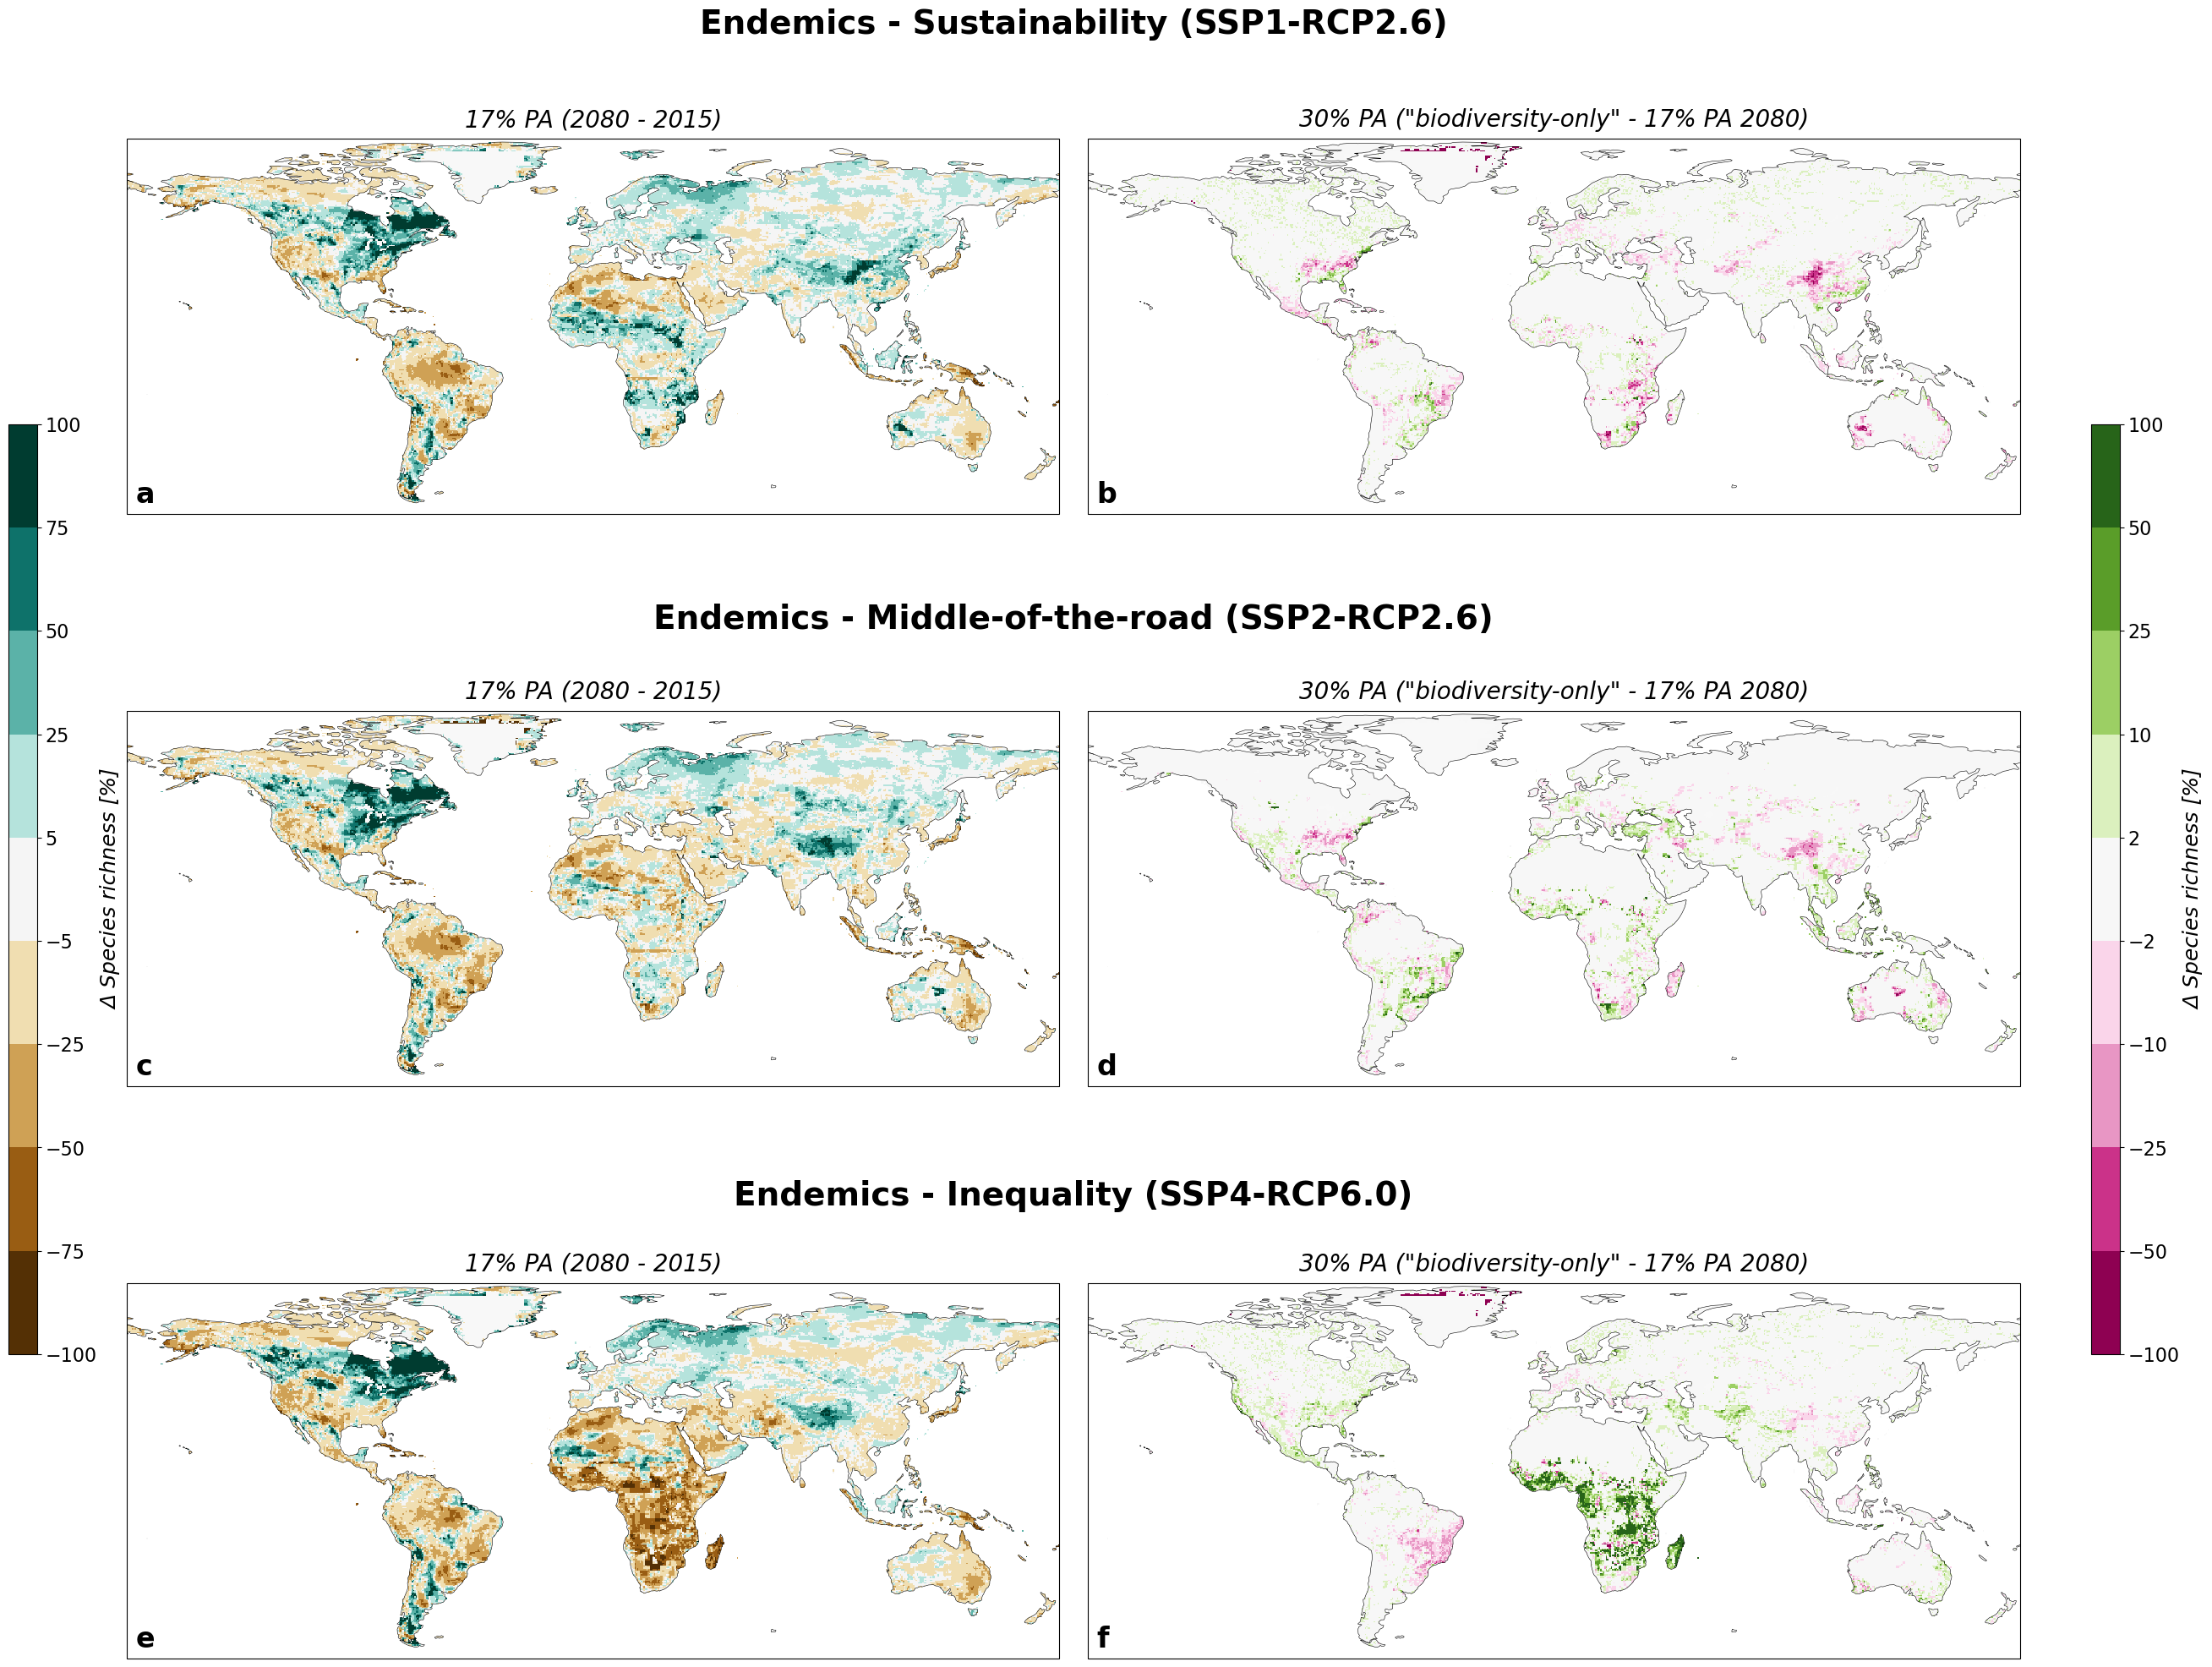

In [ ]:
#!/usr/bin/env python3
import os
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import string

warnings.filterwarnings('ignore')

# --- 1. SETUP AND PATHS ---
HIST_FILE = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/WDPA/Historical/Ensembles/total_richness_historical_2015.nc"
BASE_DIR_WDPA = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/WDPA/Baseline/Ensembles"
BASE_DIR_BIO  = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/PA30_Bio_new/Ensembles"

OUTPUT_DIR = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/Previous_results/Figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "F1_SR_2x3.png")

scenarios = ['rcp26_ssp1', 'rcp26_ssp2', 'rcp60_ssp4']
scenario_titles = {
    "rcp26_ssp1": "Endemics - Sustainability (SSP1-RCP2.6)",
    "rcp26_ssp2": "Endemics - Middle-of-the-road (SSP2-RCP2.6)",
    "rcp60_ssp4": "Endemics - Inequality (SSP4-RCP6.0)"
}

PLOT_COLS = {
    0: {'title': '17% PA (2080 - 2015)', 'calc': ('strict', 'hist')},
    1: {'title': '30% PA ("biodiversity-only" - 17% PA 2080)', 'calc': ('pa30_bio', 'strict')},
}

# Define alphabet for panel labeling (a, b, c, d, e, f)
alphabet = string.ascii_lowercase

# --- 2. HELPERS ---
def fix_coords(ds):
    if ds is None: return None
    if 'longitude' in ds.coords: ds = ds.rename({'longitude': 'lon'})
    if 'latitude' in ds.coords: ds = ds.rename({'latitude': 'lat'})
    if ds.lon.max() > 180:
        ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    return ds.sortby(['lat', 'lon'])

def load_data_file(config_type, scen_key):
    clim_rcp, lu_ssp_short = scen_key.split('_')
    ssp_map = {"ssp1": "ssp126", "ssp2": "ssp245", "ssp4": "ssp460"}
    lu_ssp = ssp_map[lu_ssp_short]

    if config_type == 'hist':
        path = HIST_FILE
    else:
        base, prefix = (BASE_DIR_WDPA, "baseline") if config_type == 'strict' else (BASE_DIR_BIO, "pa30_bio")
        # Logic to handle naming conventions on the cluster
        if lu_ssp == "ssp245":
            fname = f"total_richness_{prefix}_clim_{clim_rcp}_LU_{lu_ssp}_2080.nc"
        else:
            fname = f"total_richness_{prefix}_{clim_rcp}_2080.nc"
        path = os.path.join(base, fname)

    if not os.path.exists(path): return None
    try:
        ds = xr.open_dataset(path, decode_times=False)
        return fix_coords(ds['prob_clim_disp_luf'].squeeze()).compute()
    except: return None

# --- 3. PLOTTING SETUP ---
boundaries_left = [-100, -75, -50, -25, -5, 5, 25, 50, 75, 100]
cmap_left = plt.get_cmap('BrBG', len(boundaries_left)-1)
norm_left = BoundaryNorm(boundaries_left, cmap_left.N)

# Updated for Column 2 (30% PA) to capture the -60% minimums
boundaries_right = [-100, -50, -25, -10, -2, 2, 10, 25, 50, 100]
cmap_right = plt.get_cmap('PiYG', len(boundaries_right)-1)
norm_right = BoundaryNorm(boundaries_right, cmap_right.N)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(28, 22),
                         subplot_kw={'projection': ccrs.PlateCarree()})

plt.subplots_adjust(left=0.08, right=0.88, top=0.94, bottom=0.05, hspace=0.12, wspace=0.03)

im_left = None
im_right = None

# --- 4. PROCESSING LOOP ---
for row_idx, scen_key in enumerate(scenarios):
    # Centered Scenario Titles
    y_pos = [0.96, 0.64, 0.33] 
    fig.text(0.48, y_pos[row_idx], scenario_titles[scen_key], 
             fontsize=28, fontweight='bold', ha='center')

    for col_idx in range(2):
        ax = axes[row_idx, col_idx]
        col_params = PLOT_COLS[col_idx]
        
        m_future = load_data_file(col_params['calc'][0], scen_key)
        m_ref = load_data_file(col_params['calc'][1], scen_key)

        if m_future is not None and m_ref is not None:
            threshold = 0.01
            valid_ref = m_ref.where(m_ref > threshold)
            diff_data = (((m_future - valid_ref) / valid_ref) * 100).clip(-100, 100)

            # --- INTERNAL TERMINAL OUTPUT ---
            # Extract scalar values for records
            p_min = float(diff_data.min())
            p_max = float(diff_data.max())
            print(f"[{scen_key}] {col_params['title']} -> Min: {p_min:.2f}%, Max: {p_max:.2f}%")

            # Plotting logic
            curr_cmap, curr_norm = (cmap_left, norm_left) if col_idx == 0 else (cmap_right, norm_right)

            im = ax.pcolormesh(diff_data.lon, diff_data.lat, diff_data.values,
                               transform=ccrs.PlateCarree(), cmap=curr_cmap, 
                               norm=curr_norm, shading='auto')
            
            if col_idx == 0: im_left = im
            else: im_right = im

            # Map Aesthetics
            ax.set_extent([-180, 180, -60, 85], crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.LAND, facecolor='#f8f8f8', zorder=0)
            ax.coastlines(color="black", linewidth=0.4)
            ax.set_title(col_params['title'], fontsize=20, pad=10, style='italic')

            # Alphabet Labels (a, b, c...)
            label_idx = row_idx * 2 + col_idx
            ax.text(0.01, 0.03, alphabet[label_idx], transform=ax.transAxes,
                    fontsize=24, fontweight='bold', 
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# --- 5. COLORBARS ---
if im_left:
    cax1 = fig.add_axes([0.03, 0.25, 0.012, 0.5]) 
    cb1 = fig.colorbar(im_left, cax=cax1, orientation='vertical', ticks=boundaries_left)
    cb1.set_label('Δ Species richness [%]', fontsize=18, style='italic')
    cb1.ax.tick_params(labelsize=16)

if im_right:
    cax2 = fig.add_axes([0.91, 0.25, 0.012, 0.5]) 
    cb2 = fig.colorbar(im_right, cax=cax2, orientation='vertical', ticks=boundaries_right)
    cb2.set_label('Δ Species richness [%]', fontsize=18, style='italic')
    cb2.ax.tick_params(labelsize=16)

plt.savefig(OUTPUT_PATH, dpi=500, bbox_inches='tight')
print(f"\n✅ Figure saved at: {OUTPUT_PATH}")

FIGURE 2

Biodiverstiy-only optimization (30% PA), withPA, no "biome", Jung et al. (2021)

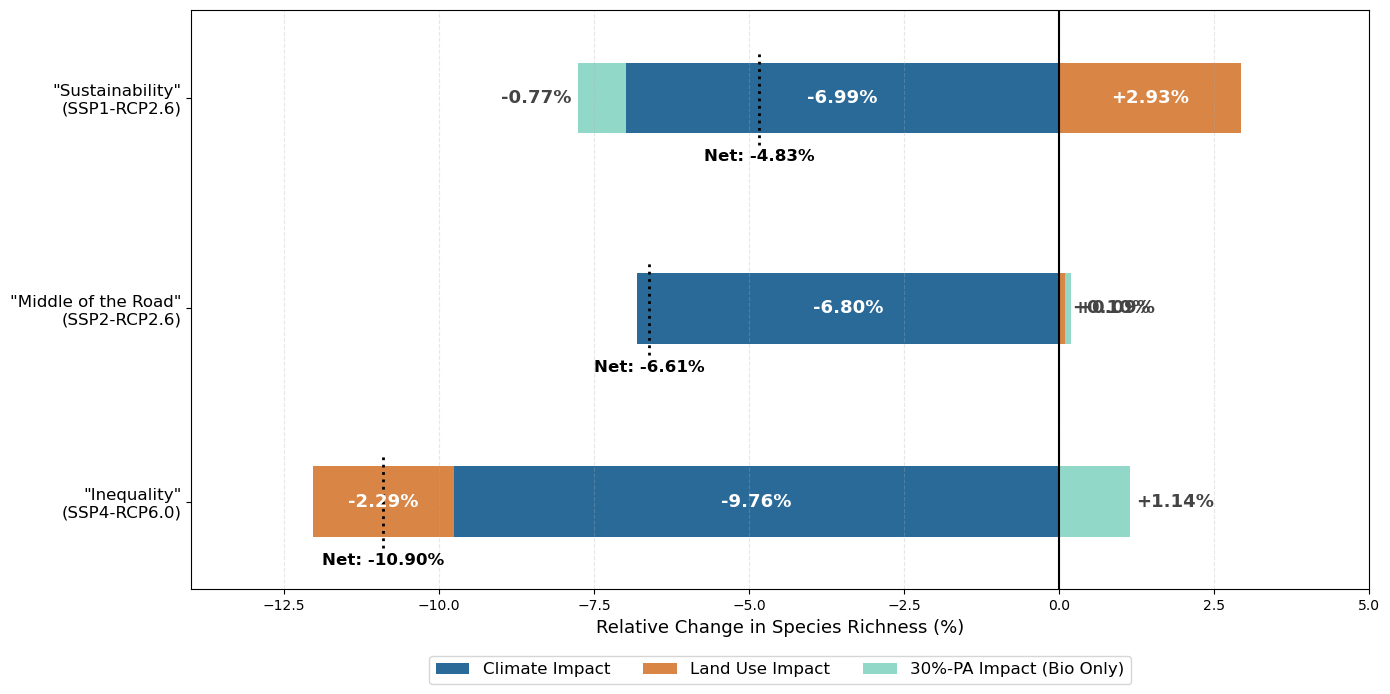

In [5]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# --- 1. SETTINGS & PATHS ---
WDPA_ROOT = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/WDPA"
BIO_ROOT = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/PA30_Bio_new"

scen_configs = [
    ('rcp26', 'ssp126'), 
    ('rcp26', 'ssp245'), 
    ('rcp60', 'ssp460')
]

def get_weighted_mean(ds, weights):
    var = 'prob_clim_disp_luf'
    return ds[var].weighted(weights).mean(dim=['lat', 'lon']).item()

# --- 2. DATA PROCESSING ---
ds_hist = xr.open_dataset(os.path.join(WDPA_ROOT, "Historical/Ensembles/total_richness_historical_2015.nc"))
weights = np.cos(np.deg2rad(ds_hist.lat))
h_val = get_weighted_mean(ds_hist, weights)

results = []
for clim_sce, lu_sce in scen_configs:
    if lu_sce == 'ssp245':
        f_base, f_clim, f_bio = f"total_richness_baseline_clim_{clim_sce}_LU_{lu_sce}_2080.nc", f"total_richness_climate_only_clim_{clim_sce}_LU_{lu_sce}_2080.nc", f"total_richness_pa30_bio_clim_{clim_sce}_LU_{lu_sce}_2080.nc"
        label = f"\"Middle of the Road\"\n(SSP2-RCP2.6)"
    else:
        f_base, f_clim, f_bio = f"total_richness_baseline_{clim_sce}_2080.nc", f"total_richness_climate_only_{clim_sce}_2080.nc", f"total_richness_pa30_bio_{clim_sce}_2080.nc"
        label = "\"Sustainability\"\n(SSP1-RCP2.6)" if lu_sce == 'ssp126' else "\"Inequality\"\n(SSP4-RCP6.0)"

    ds_clim = xr.open_dataset(os.path.join(WDPA_ROOT, f"Climate_Only/Ensembles/{f_clim}"))
    ds_base = xr.open_dataset(os.path.join(WDPA_ROOT, f"Baseline/Ensembles/{f_base}"))
    ds_bio  = xr.open_dataset(os.path.join(BIO_ROOT,  f"Ensembles/{f_bio}"))
    
    c_val, b_val, bio_val = get_weighted_mean(ds_clim, weights), get_weighted_mean(ds_base, weights), get_weighted_mean(ds_bio, weights)

    results.append({
        'Label': label,
        'Climate': (c_val - h_val) / h_val * 100,
        'Land Use': (b_val - c_val) / h_val * 100,
        'Exp_Bio': (bio_val - b_val) / h_val * 100
    })

df = pd.DataFrame(results)

# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.array([2.4, 1.2, 0.1])
width = 0.4 
colors = {'Climate': '#2a6a98', 'Land Use': '#d88546', 'Exp_Bio': '#92d8c8'}

for i, row in df.iterrows():
    y = y_pos[i]
    left_pos, left_neg = 0, 0
    drivers = [('Climate', row['Climate']), ('Land Use', row['Land Use']), ('Exp_Bio', row['Exp_Bio'])]
    
    for key, val in drivers:
        if key == 'Exp_Bio': display_lab = '30%-PA Impact (Bio Only)'
        elif key == 'Climate': display_lab = 'Climate Impact'
        else: display_lab = 'Land Use Impact'
        
        current_label = display_lab if i == 0 else ""
        current_color = colors[key]
        
        # Color Logic: Dark gray and white shadow
        # 1. First, set the default color for Exp_Bio (always gray)
        if key == 'Exp_Bio':
            text_color = '#444444'
        else:
            # 2. For Climate/Land Use, including outside and inside settings (< 1.2%)
            # If outside, gray is better for readability on white background
            if abs(val) < 1.2:
                text_color = '#444444'
            else:
                text_color = 'white'
        
        if val >= 0:
            ax.barh(y, val, left=left_pos, height=width, color=current_color, label=current_label)
            x_pos = (left_pos + val + 0.1) if abs(val) < 1.2 else (left_pos + val/2)
            ha_val = 'left' if abs(val) < 1.2 else 'center'
            
            ax.text(x_pos, y, f"{val:+.2f}%", va='center', ha=ha_val, fontsize=13, 
                    fontweight='bold', color=text_color)
            left_pos += val
        else:
            ax.barh(y, val, left=left_neg, height=width, color=current_color, label=current_label)
            x_pos = (left_neg + val - 0.1) if abs(val) < 1.2 else (left_neg + val/2)
            ha_val = 'right' if abs(val) < 1.2 else 'center'
            
            ax.text(x_pos, y, f"{val:+.2f}%", va='center', ha=ha_val, fontsize=13, 
                    fontweight='bold', color=text_color)
            left_neg += val

    # Net Value
    net_val = row['Climate'] + row['Land Use'] + row['Exp_Bio']
    ax.vlines(x=net_val, ymin=y-width/1.5, ymax=y+width/1.5, color='black', linestyle=':', linewidth=2)
    ax.text(net_val, y - 0.36, f"Net: {net_val:+.2f}%", ha='center', fontsize=12, color='black', fontweight='bold')

# Aesthetics
ax.axvline(0, color='black', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(df['Label'], fontsize=12)
ax.set_xlabel('Relative Change in Species Richness (%)', fontsize=13)
ax.set_xlim(-14, 5)
ax.set_ylim(y_pos.min() - 0.5, y_pos.max() + 0.5)
ax.grid(axis='x', linestyle='--', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
unique_map = {l: h for h, l in zip(handles, labels) if l != ""}
ax.legend(unique_map.values(), unique_map.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=True, fontsize=12)

plt.tight_layout()
plt.show()

Figure 3. Global relative change in SR per taxonomic group


SUMMARY TABLE: MEAN % CHANGE ± MODEL UNCERTAINTY (STDEV) PER TAXA
   Scenario       Taxa         17% PA       30% PA (BIO)    30% PA (BCW) 
Sustainability Amphibians  -9.35% ±  3.00  -9.97% ±  2.98  -9.25% ±  3.02
Sustainability      Birds  -3.35% ±  1.56  -4.17% ±  1.54  -3.47% ±  1.56
Sustainability    Mammals  -2.52% ±  4.72  -3.30% ±  4.68  -2.54% ±  4.71
    Inequality Amphibians -17.27% ±  4.43 -16.17% ±  4.34 -15.89% ±  4.39
    Inequality      Birds -12.44% ±  2.46 -11.34% ±  2.41 -11.37% ±  2.42
    Inequality    Mammals  -8.85% ±  4.13  -7.63% ±  4.13  -7.61% ±  4.14


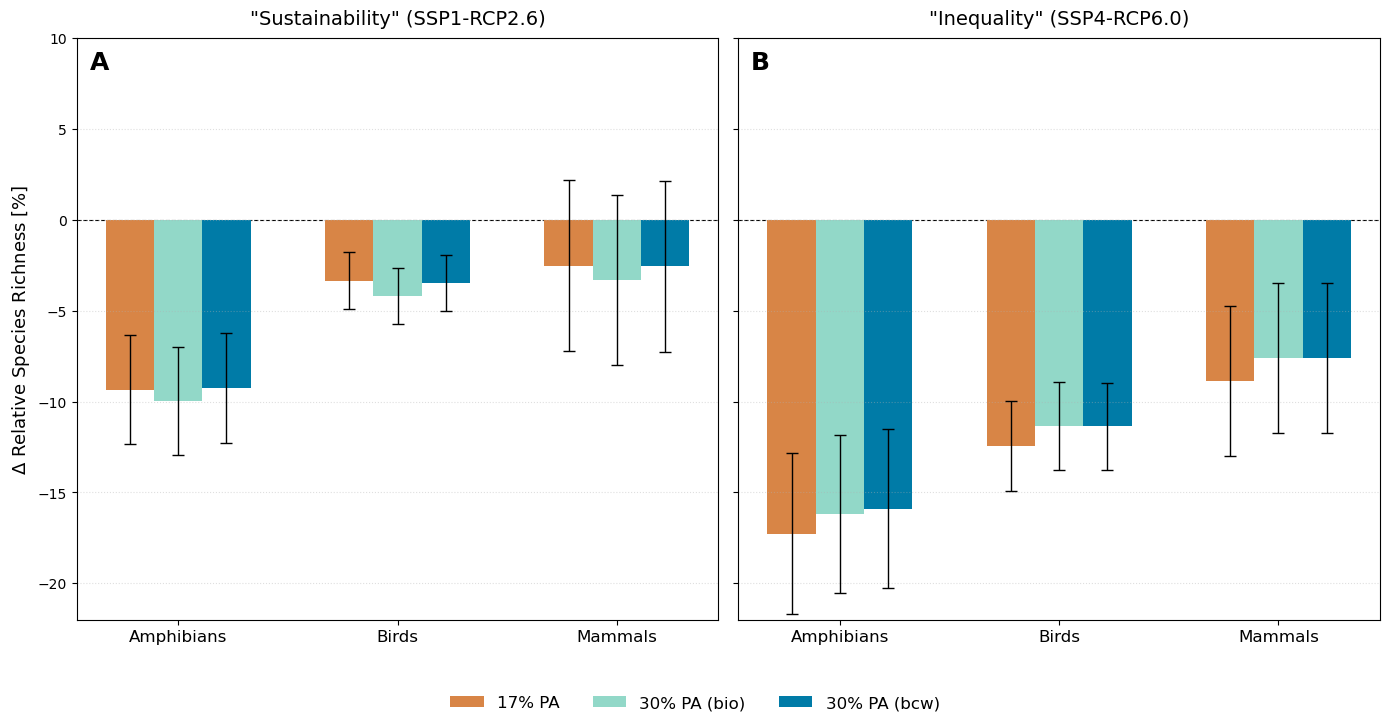

In [ ]:
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETTINGS & PATHS ---
# Using defined folder structure
ROOT_17 = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/WDPA"
ROOT_BIO = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/PA30_Bio_new"
ROOT_BCW = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob/PA30_BCW_new"

taxas = ["Amphibians", "Bird", "Mammals"]
# Mapping dictionary
taxa_display = {"Amphibians": "Amphibians", "Bird": "Birds", "Mammals": "Mammals"}
scenarios = ["rcp26", "rcp60"]
scenarios = ["rcp26", "rcp60"]

# Categories to plot
cats = ["17", "bio", "bcw"]

# Dictionaries to store values
relative_differences = {s: {t: {c: None for c in cats} for t in taxas} for s in scenarios}
std_devs = {s: {t: {c: 0 for c in cats} for t in taxas} for s in scenarios}

# --- 2. DATA EXTRACTION ---
for t in taxas:
    # Historical baseline for normalization
    hist_file = os.path.join(ROOT_17, f"Historical/Ensembles/{t}_historical_2015.nc")
    with xr.open_dataset(hist_file) as ds_hist:
        weights = np.cos(np.deg2rad(ds_hist.lat))
        h_val_taxa = ds_hist['prob_clim_disp_luf'].weighted(weights).mean().item()

    for sce in scenarios:
        # Glob patterns for the three expansion types
        f_lists = {
            "17":  glob.glob(f"{ROOT_17}/Baseline/summed_prob_{t}_*_{sce}_2080_wdpa17.nc"),
            "bio": glob.glob(f"{ROOT_BIO}/summed_prob_{t}_*_{sce}_2080_pa30_bio.nc"),
            "bcw": glob.glob(f"{ROOT_BCW}/summed_prob_{t}_*_{sce}_2080_pa30_bcw.nc")
        }
        
        def calculate_impact(file_list, reference):
            res = []
            for f in file_list:
                if "Bird_GBM" in f: continue
                with xr.open_dataset(f) as ds:
                    v = ds['prob_clim_disp_luf'].weighted(weights).mean().item()
                    res.append((v - reference) / reference * 100)
            return res

        for c in cats:
            samps = calculate_impact(f_lists[c], h_val_taxa)
            if samps:
                relative_differences[sce][t][c] = {
                    "median": np.median(samps),
                    "mean": np.mean(samps)
                }
                std_devs[sce][t][c] = np.std(samps, ddof=1)

# --- 3. PLOTTING ---
colors = {
    "17":  "#d88546",  # Baseline orange
    "bio": "#92d8c8",  # Bio Only blue aqua
    "bcw": "#007BA7",  # BCW blue
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
titles = {"rcp26": '"Sustainability" (SSP1-RCP2.6)', "rcp60": '"Inequality" (SSP4-RCP6.0)'}
labels = ['A', 'B']

for i, sce in enumerate(scenarios):
    ax = axes[i]
    x = np.arange(len(taxas))
    
    # Adjusted for 3 bars
    bar_width = 0.22
    offsets = [-bar_width, 0, bar_width]

    for idx, c in enumerate(cats):
        vals = [relative_differences[sce][t][c]["mean"] for t in taxas]
        errs = [std_devs[sce][t][c] for t in taxas]
        leg_lab = "17% PA" if c=="17" else f"30% PA ({c.lower()})"
        
        ax.bar(x + offsets[idx], vals, bar_width, label=leg_lab if i==0 else "", 
               color=colors[c], yerr=errs, capsize=4, error_kw={'elinewidth':1})

    # Labels and Titles
    ax.set_title(titles[sce], loc='center', fontsize=14, pad=10)
    
    # 2. Inside Panel Label (A and B)
    # Using transform=ax.transAxes makes (0,0) bottom-left and (1,1) top-right of the plot
    ax.text(0.02, 0.98, labels[i], 
            transform=ax.transAxes, 
            fontsize=18, 
            fontweight='bold', 
            va='top', 
            ha='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2)) # Adds a soft white background for legibility


    ax.set_xticks(x)
    ax.set_xticklabels(taxa_display.values(), fontsize=12)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, zorder=0)
    ax.set_ylim(-22, 10) 
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    if i == 0: 
        ax.set_ylabel('$\Delta$ Relative Species Richness [%]', fontsize=13)

# Legend Configuration
handles, plot_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, plot_labels, loc="upper center", ncol=3, 
           bbox_to_anchor=(0.5, 0.02), fontsize=12, frameon=False)

import pandas as pd

# --- 4. SUMMARY TABLE ---
print("\n" + "="*85)
print("SUMMARY TABLE: MEAN % CHANGE ± MODEL UNCERTAINTY (STDEV) PER TAXA")
print("="*85)

summary_rows = []

for sce in scenarios:
    for t in taxas:
        row = {
            'Scenario': titles[sce].split(' (')[0].replace('"', ''), # e.g., Sustainability
            'Taxa': taxa_display[t]
        }
        for c in cats:
            mean_val = relative_differences[sce][t][c]["mean"]
            std_val = std_devs[sce][t][c]
            
            # Formatting column name and value
            col_name = "17% PA" if c == "17" else f"30% PA ({c.upper()})"
            row[col_name] = f"{mean_val:6.2f}% ± {std_val:5.2f}"
            
        summary_rows.append(row)

# Create DataFrame
df_summary = pd.DataFrame(summary_rows)

# Print to console
print(df_summary.to_string(index=False, justify='center'))

# Optional: Export to CSV if needed
df_summary.to_csv("taxa_summary_results.csv", index=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Figure 4. Subregional analysis (Management effectiveness)

3 PA scenarios (17% PA, 30%-PA Bio only and 30%-PA BWC), 2 SSP-RCP, IPBES Subregions

Processing rcp26...
Processing rcp60...


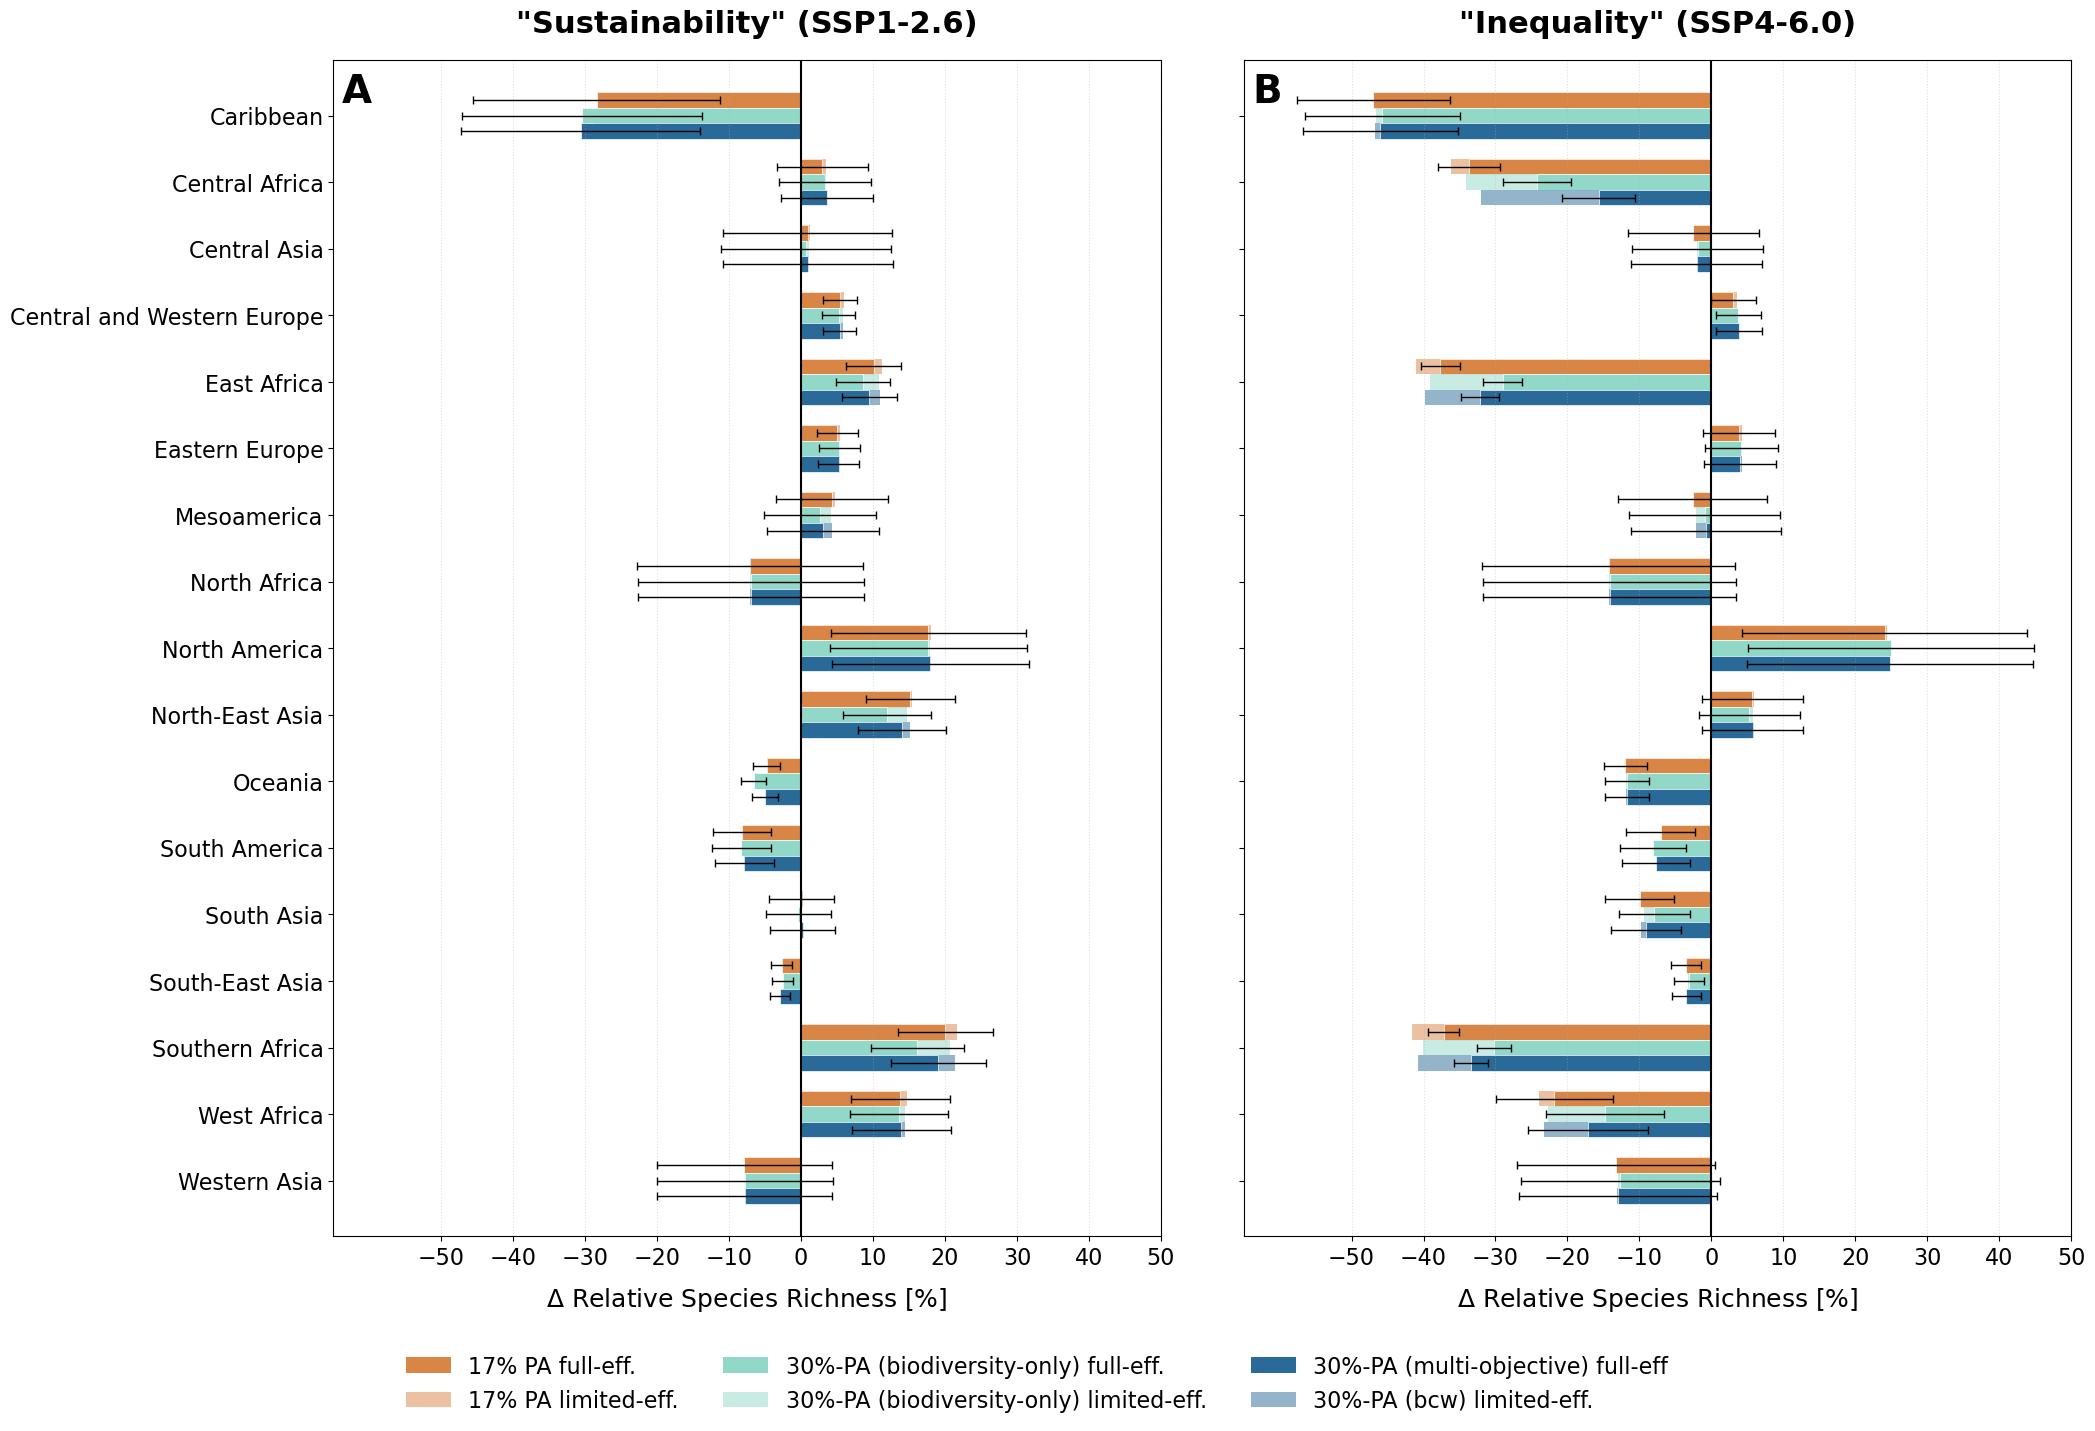

In [19]:
import os
import xarray as xr
import geopandas as gpd
import pandas as pd
import numpy as np
from rasterio import features
from affine import Affine
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D 

# --- 1. CONFIGURATION ---
BASE_PATH = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob"
SHP_PATH  = "/capacity/occr_davin/chari/P1/IPBES_subregions/IPBES_Regions_Subregions2.shp"
TAXAS = ["Amphibians", "Bird", "Mammals"]
SDMS = ["GAM", "GBM"]
GCMS = ["GFDL-ESM2M", "IPSL-CM5A-LR", "HadGEM2-ES", "MIROC5"]
SCENARIOS = ["rcp26", "rcp60"]

# Categories and their specific folder/suffix 
CAT_CONFIG = {
    "17": ("WDPA/Baseline", "wdpa17"),
    "bio": ("PA30_Bio_new", "pa30_bio"),
    "bcw": ("PA30_BCW_new", "pa30_bcw")
}

# --- 2. GRID & WEIGHTS ---
hist_f = os.path.join(BASE_PATH, "WDPA/Baseline/Ensembles/total_richness_baseline_rcp26_2080.nc") # Using as template
ds_hist = xr.open_dataset(os.path.join(BASE_PATH, "WDPA/Historical/Ensembles/total_richness_historical_2015.nc"))['prob_clim_disp_luf'].load()

res_lon = (ds_hist.lon[1] - ds_hist.lon[0]).item()
res_lat = (ds_hist.lat[1] - ds_hist.lat[0]).item()
transform = Affine.translation(ds_hist.lon[0] - res_lon/2, ds_hist.lat[0] - res_lat/2) * Affine.scale(res_lon, res_lat)

lat_weights = np.cos(np.deg2rad(ds_hist.lat.values))
global_weights = np.broadcast_to(lat_weights[:, np.newaxis], ds_hist.shape)

shp = gpd.read_file(SHP_PATH)
region_mapping = {
    'Caribbean': 'Caribbean', 'Central Africa': 'Central Africa',
    'Central and Western Europe': 'Central and Western Europe', 'Central Asia': 'Central Asia',
    'East Africa and adjacent islands': 'East Africa', 'Eastern Europe': 'Eastern Europe',
    'Mesoamerica': 'Mesoamerica', 'North Africa': 'North Africa',
    'North America': 'North America', 'North-East Asia': 'North-East Asia',
    'Oceania': 'Oceania', 'South America': 'South America', 'South Asia': 'South Asia',
    'South-East Asia': 'South-East Asia', 'Southern Africa': 'Southern Africa',
    'West Africa': 'West Africa', 'Western Asia': 'Western Asia'
}
shp['new_region'] = shp['Sub_Region'].map(region_mapping)
unique_regions = sorted(shp['new_region'].dropna().unique())
region_masks = {r: features.rasterize(shp[shp['new_region'] == r].geometry, 
                out_shape=ds_hist.shape, transform=transform, fill=0, default_value=1).astype(bool) 
                for r in unique_regions}

# --- 3. DATA EXTRACTION ---
results_full = {s: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for s in SCENARIOS}
results_lim = {s: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for s in SCENARIOS}

for sce in SCENARIOS:
    print(f"Processing {sce}...")
    for cat_key, (sub_dir, suffix) in CAT_CONFIG.items():
        base_dir = os.path.join(BASE_PATH, sub_dir)
        
        for sdm in SDMS:
            for gcm in GCMS:
                member_sum_f, member_sum_l = None, None
                
                for taxa in TAXAS:
                    current_sdm = "GAM" if (taxa == "Bird" and sdm == "GBM") else sdm
                    f_full = os.path.join(base_dir, f"summed_prob_{taxa}_{current_sdm}_{gcm}_{sce}_2080_{suffix}.nc")
                    f_lim = os.path.join(base_dir, f"lim_eff_summed_prob_{taxa}_{current_sdm}_{gcm}_{sce}_2080_{suffix}.nc")

                    if os.path.exists(f_full):
                        with xr.open_dataset(f_full) as ds:
                            data = ds['prob_clim_disp_luf'].load()
                            member_sum_f = data if member_sum_f is None else member_sum_f + data
                    
                    if os.path.exists(f_lim):
                        with xr.open_dataset(f_lim) as ds:
                            data_l = ds['prob_clim_disp_luf'].load()
                            member_sum_l = data_l if member_sum_l is None else member_sum_l + data_l

                
                if member_sum_f is not None:
                    diff = ((member_sum_f - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        # Flatten to check values
                        m_vals = diff.values[mask]
                        w_vals = global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_full[sce][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))

                if member_sum_l is not None:
                    diff_l = ((member_sum_l - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        m_vals = diff_l.values[mask]
                        w_vals = global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_lim[sce][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))



# --- 4. PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(22, 14), sharey=True) 
colors = {'17': '#d88546', 'bio': '#92d8c8', 'bcw': '#2a6a98'}

bar_width = 0.28
indices = np.arange(len(unique_regions)) * 1.2  # Added multiplier for inter-region spacing
offsets = [-bar_width, 0, bar_width]
titles = {"rcp26": '"Sustainability" (SSP1-2.6)', "rcp60": '"Inequality" (SSP4-6.0)'}

for i, sce in enumerate(SCENARIOS):
    ax = axes[i]
    for idx, c in enumerate(['17', 'bio', 'bcw']):
        m_f = [np.mean(results_full[sce][c][r]) if results_full[sce][c][r] else 0 for r in unique_regions]
        s_f = [np.std(results_full[sce][c][r], ddof=1) if len(results_full[sce][c][r]) > 1 else 0 for r in unique_regions]
        m_l = [np.mean(results_lim[sce][c][r]) if results_lim[sce][c][r] else 0 for r in unique_regions]
        
        y_pos = indices + offsets[idx]
        
        # Plot Limited Effectiveness (Ghosted background)
        ax.barh(y_pos, m_l, bar_width, color=colors[c], alpha=0.5)
        
        # Plot Full Effectiveness (Primary bars)
        ax.barh(y_pos, m_f, bar_width, color=colors[c], xerr=s_f, 
                error_kw={'capsize': 3, 'elinewidth': 1, 'alpha': 1.0},
                edgecolor='white', linewidth=0.5)

    # Styling for clarity and scale
    ax.set_yticks(indices)
    if i == 0:
        ax.set_yticklabels(unique_regions, fontsize=16, fontweight='medium')
    
    ax.set_title(titles[sce], fontsize=22, pad=20, fontweight='bold')
    ax.invert_yaxis()
    
    # FIXED SCALE: Force -50 to 50 for clarity
    ax.set_xlim(-65, 50)
    ax.set_xticks([-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
    ax.tick_params(axis='x', 
                   labelsize=16)
    
    ax.grid(axis='x', linestyle=':', alpha=0.4, zorder=0)
    ax.axvline(0, color='black', lw=1.5, zorder=3)
    ax.set_xlabel(r'$\Delta$ Relative Species Richness [%]', fontsize=18, labelpad=12)
    
    
    # Tighten vertical space to prevent "floating" labels
    ax.set_ylim(indices[-1] + 1, indices[0] - 1)
    
    # Panel labels consistent with previous figures
    ax.text(0.01, 0.99, ['A', 'B'][i], transform=ax.transAxes, 
            fontsize=28, fontweight='bold', va='top')

# Legend with descriptive labels for PA scenarios
legend_elements = [
    Patch(facecolor=colors['17'], alpha=1.0, label='17% PA full-eff.'),
    Patch(facecolor=colors['17'], alpha=0.5, label='17% PA limited-eff.'),
    Patch(facecolor=colors['bio'], alpha=1.0, label='30%-PA (biodiversity-only) full-eff.'),
    Patch(facecolor=colors['bio'], alpha=0.5, label='30%-PA (biodiversity-only) limited-eff.'),
    Patch(facecolor=colors['bcw'], alpha=1.0, label='30%-PA (multi-objective) full-eff'),
    Patch(facecolor=colors['bcw'], alpha=0.5, label='30%-PA (bcw) limited-eff.')
]

fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, -0.06), fontsize=16, frameon=False)

plt.subplots_adjust(left=0.18, right=0.97, top=0.92, bottom=0.08, wspace=0.1)
plt.show()

Table S2. Results per subregions, SSP-RCP scenario and PA scenario

In [ ]:
import os
import xarray as xr
import geopandas as gpd
import pandas as pd
import numpy as np
from rasterio import features
from affine import Affine

# --- 1. CONFIGURATION ---
BASE_PATH = "/capacity/occr_davin/mguzman/chari_P2_review/Endemics/PA_scenarios/Sumprob"
SHP_PATH  = "/capacity/occr_davin/chari/P1/IPBES_subregions/IPBES_Regions_Subregions2.shp"
TAXAS = ["Amphibians", "Bird", "Mammals"]
SDMS = ["GAM", "GBM"]
GCMS = ["GFDL-ESM2M", "IPSL-CM5A-LR", "HadGEM2-ES", "MIROC5"]

# Define the three specific Scenario-SSP combinations
# Format: (short_name, climate_rcp, landuse_ssp)
SCENARIO_LIST = [
    ("Sustainability (SSP1-2.6)", "rcp26", "ssp1"),
    ("Middle-of-the-road (SSP2-2.6)", "rcp26", "ssp2"),
    ("Inequality (SSP4-6.0)", "rcp60", "ssp4")
]

CAT_CONFIG = {
    "17": ("WDPA/Baseline", "wdpa17"),
    "bio": ("PA30_Bio_new", "pa30_bio"),
    "bcw": ("PA30_BCW_new", "pa30_bcw")
}

# --- 2. GRID & WEIGHTS ---
# Using 2015 historical as the reference point
ds_hist = xr.open_dataset(os.path.join(BASE_PATH, "WDPA/Historical/Ensembles/total_richness_historical_2015.nc"))['prob_clim_disp_luf'].load()

res_lon = (ds_hist.lon[1] - ds_hist.lon[0]).item()
res_lat = (ds_hist.lat[1] - ds_hist.lat[0]).item()
transform = Affine.translation(ds_hist.lon[0] - res_lon/2, ds_hist.lat[0] - res_lat/2) * Affine.scale(res_lon, res_lat)

lat_weights = np.cos(np.deg2rad(ds_hist.lat.values))
global_weights = np.broadcast_to(lat_weights[:, np.newaxis], ds_hist.shape)

shp = gpd.read_file(SHP_PATH)
shp['new_region'] = shp['Sub_Region'] # Simplified mapping
unique_regions = sorted(shp['new_region'].dropna().unique())
region_masks = {r: features.rasterize(shp[shp['new_region'] == r].geometry, 
                out_shape=ds_hist.shape, transform=transform, fill=0, default_value=1).astype(bool) 
                for r in unique_regions}

# --- 3. DATA EXTRACTION ---
# Initializing nested dicts for all 3 scenarios
results_full = {name: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for name, _, _ in SCENARIO_LIST}
results_lim = {name: {c: {r: [] for r in unique_regions} for c in CAT_CONFIG} for name, _, _ in SCENARIO_LIST}

# --- 3. DATA EXTRACTION (Updated for SSP2 naming) ---
for name, sce_rcp, sce_ssp in SCENARIO_LIST:
    print(f"Processing {name}...")
    for cat_key, (sub_dir, suffix) in CAT_CONFIG.items():
        base_dir = os.path.join(BASE_PATH, sub_dir)
        
        # Handle the extra land-use string for SSP2 specifically
        lu_suffix = "_LU_ssp245" if sce_ssp == "ssp2" else ""
        
        for sdm in SDMS:
            for gcm in GCMS:
                member_sum_f, member_sum_l = None, None
                
                for taxa in TAXAS:
                    current_sdm = "GAM" if (taxa == "Bird" and sdm == "GBM") else sdm
                    
                    # f_full example: ...rcp26_2080_LU_ssp245_pa30_bcw.nc
                    f_full = os.path.join(base_dir, f"summed_prob_{taxa}_{current_sdm}_{gcm}_{sce_rcp}_2080{lu_suffix}_{suffix}.nc")
                    f_lim = os.path.join(base_dir, f"lim_eff_summed_prob_{taxa}_{current_sdm}_{gcm}_{sce_rcp}_2080{lu_suffix}_{suffix}.nc")

                    if os.path.exists(f_full):
                        with xr.open_dataset(f_full) as ds:
                            data = ds['prob_clim_disp_luf'].load()
                            member_sum_f = data if member_sum_f is None else member_sum_f + data
                    else:
                        # Optional: Print missing files for SSP2 debugging
                        if sce_ssp == "ssp2":
                            print(f"      Missing: {os.path.basename(f_full)}")
                    
                    if os.path.exists(f_lim):
                        with xr.open_dataset(f_lim) as ds:
                            data_l = ds['prob_clim_disp_luf'].load()
                            member_sum_l = data_l if member_sum_l is None else member_sum_l + data_l


                # Global and Regional Weighted Average Calculation
                if member_sum_f is not None:
                    diff = ((member_sum_f - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        m_vals, w_vals = diff.values[mask], global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_full[name][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))

                if member_sum_l is not None:
                    diff_l = ((member_sum_l - ds_hist) / ds_hist.where(ds_hist > 0)) * 100
                    for r in unique_regions:
                        mask = region_masks[r]
                        m_vals, w_vals = diff_l.values[mask], global_weights[mask]
                        valid = ~np.isnan(m_vals)
                        if valid.any():
                            results_lim[name][cat_key][r].append(np.average(m_vals[valid], weights=w_vals[valid]))

# --- 4. SUMMARY TABLE GENERATION ---
print("\n" + "="*100)
print("FINAL SUMMARY: MEAN % CHANGE ± MODEL UNCERTAINTY (GCMs/SDMs)")
print("="*100)

summary_cats = ['17', 'bio', 'bcw']
eff_levels = [(results_full, "FULL EFFECTIVENESS"), (results_lim, "LIMITED EFFECTIVENESS")]

all_dfs = []

for results_dict, eff_label in eff_levels:
    for c in summary_cats:
        print(f"\n[ CATEGORY: {c.upper()} - {eff_label} ]")
        rows = []
        for r in unique_regions:
            res_row = {'Region': r, 'Management': eff_label, 'Category': c}
            for name, _, _ in SCENARIO_LIST:
                member_data = results_dict[name][c][r]
                if member_data:
                    mean_val = np.mean(member_data)
                    std_val = np.std(member_data, ddof=1)
                    res_row[name] = f"{mean_val:6.2f}% ± {std_val:5.2f}"
                else:
                    res_row[name] = "N/A"
            rows.append(res_row)
        
        df_cat = pd.DataFrame(rows)
        print(df_cat.drop(columns=['Management', 'Category']).to_string(index=False, justify='center'))
        all_dfs.append(df_cat)

# Export complete consolidated data
final_df = pd.concat(all_dfs)
final_df.to_csv("/capacity/occr_davin/mguzman/chari_P2_review/Endemics/Previous_results/Subregions_3Scenarios_Summary.csv", index=False)

Processing Sustainability (SSP1-2.6)...
Processing Middle-of-the-road (SSP2-2.6)...
Processing Inequality (SSP4-6.0)...

FINAL SUMMARY: MEAN % CHANGE ± MODEL UNCERTAINTY (GCMs/SDMs)

[ CATEGORY: 17 - FULL EFFECTIVENESS ]
             Region              Sustainability (SSP1-2.6) Middle-of-the-road (SSP2-2.6) Inequality (SSP4-6.0)
                      Antarctica                  N/A                         N/A                       N/A   
                       Caribbean      -28.40% ± 17.18             -32.95% ± 16.03           -47.01% ± 10.64   
                  Central Africa        2.98% ±  6.32              -4.02% ±  6.16           -33.74% ±  4.29   
                    Central Asia        0.93% ± 11.76               0.88% ± 11.74            -2.51% ±  9.08   
      Central and Western Europe        5.45% ±  2.34               2.05% ±  2.28             3.04% ±  3.11   
East Africa and adjacent islands       10.08% ±  3.85              -4.34% ±  3.27           -37.67% ±  2.69   
  